In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
ds = pd.read_csv('outliee_height.csv')
ds

,NAME,HEIGHT
0,KARAN,1.2
1,JAVED,2.9
2,SOHAN,4.9
3,MAHIMA,4.8
4,JOHN,5.1
5,KRISHNA,5.4
6,KAMINI,5.2
7,GAGAN,5.8
8,RAM,5.6
9,RAVI,5.7


<Axes: ylabel='HEIGHT'>

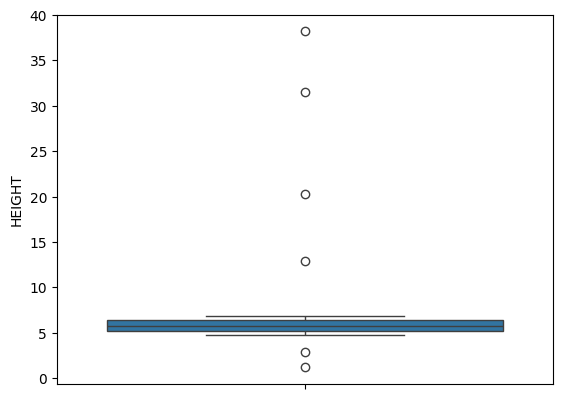

In [37]:
orignal_data = ds.copy()  
sns.boxplot(orignal_data['HEIGHT'])

In [39]:
q1 = ds['HEIGHT'].quantile(0.25)
q3 = ds['HEIGHT'].quantile(0.75)
iqr = q3 - q1
iqr

np.float64(1.2000000000000002)

In [40]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(upper_bound)
print(lower_bound)

8.175
3.3749999999999996


In [41]:
# shoing the how many outliear in the Height columns 
ds[(ds['HEIGHT'] > upper_bound) | (ds['HEIGHT'] < lower_bound)]

,NAME,HEIGHT
0,KARAN,1.2
1,JAVED,2.9
16,GYAN,12.9
17,KOMAL,20.3
18,CHANDAN,31.5
19,DINESH,38.2


In [42]:
# remove the outliear using set the limits 
ds = ds[(ds['HEIGHT'] > lower_bound) & (ds['HEIGHT'] < upper_bound)] 
ds

,NAME,HEIGHT
2,SOHAN,4.9
3,MAHIMA,4.8
4,JOHN,5.1
5,KRISHNA,5.4
6,KAMINI,5.2
7,GAGAN,5.8
8,RAM,5.6
9,RAVI,5.7
10,TANU,5.8
11,RINI,6.1


<Axes: >

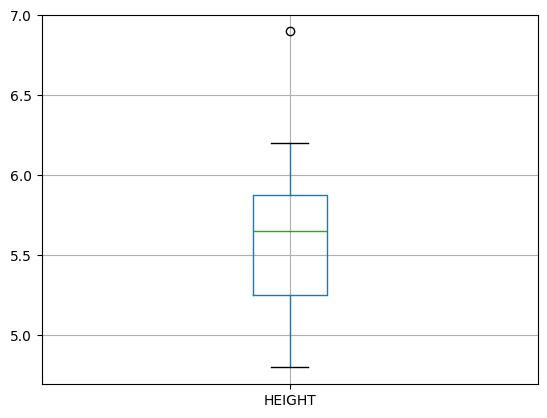

In [43]:
ds.boxplot()

<Axes: xlabel='HEIGHT'>

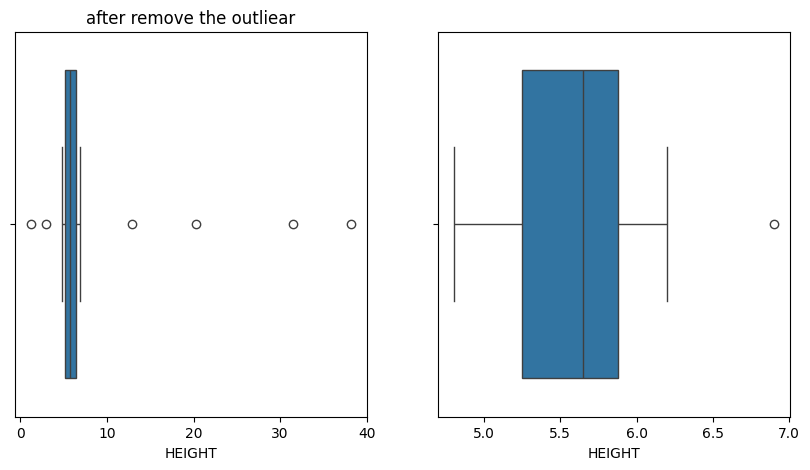

In [52]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('after remove the outliear')
# plt.xticks(rotation = 90)
sns.boxplot(x = orignal_data['HEIGHT'])
plt.subplot(1,2,2)
sns.boxplot(x = ds['HEIGHT'])


* Boxplot outliers ≠ IQR outliers
# ➤ Outliers remove karne ke baad
* New dataset ka Q1, Q3, IQR change ho jata hai.

In [57]:
# again i calclate the iqr and remove last outliear 
Q1 = ds['HEIGHT'].quantile(0.25)
Q3 = ds['HEIGHT'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
IQR
ds[(ds['HEIGHT'] > lower) | (ds['HEIGHT'] < upper)] # so 6.9 is the outliear 

,NAME,HEIGHT
2,SOHAN,4.9
3,MAHIMA,4.8
4,JOHN,5.1
5,KRISHNA,5.4
6,KAMINI,5.2
7,GAGAN,5.8
8,RAM,5.6
9,RAVI,5.7
10,TANU,5.8
11,RINI,6.1


In [59]:
ds = ds[(ds['HEIGHT'] >= lower) & (ds['HEIGHT'] <= upper)]
ds[(ds['HEIGHT'] >= lower) | (ds['HEIGHT'] <= upper )]

,NAME,HEIGHT
2,SOHAN,4.9
3,MAHIMA,4.8
4,JOHN,5.1
5,KRISHNA,5.4
6,KAMINI,5.2
7,GAGAN,5.8
8,RAM,5.6
9,RAVI,5.7
10,TANU,5.8
11,RINI,6.1


<Axes: ylabel='HEIGHT'>

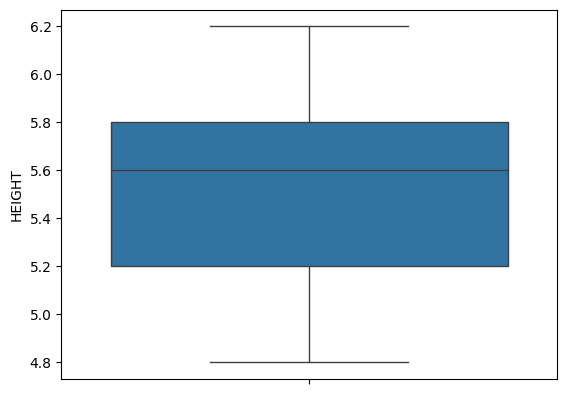

In [60]:
sns.boxplot(ds['HEIGHT'])